In [32]:
import torch
import numpy as np
import torchvision
from torchvision import models, transforms


In [8]:
print("Pytorch version:" , torch.__version__)
print("Torchvision version: ", torchvision.__version__)

Pytorch version: 2.5.1
Torchvision version:  0.20.1


## load model

In [56]:
from torchvision.models import VGG16_Weights
use_pretrained = True
net = models.vgg16(weights = VGG16_Weights) # model with 13 conv layers and 3 full-connected l
net.eval() # evaluation model
print(net)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [49]:
class BaseTransform:
    def __init__(self, resize, mean, std):
        self.base_transform = transforms.Compose([
            transforms.Resize(resize),
            transforms.CenterCrop(resize), #output 224x224
            transforms.ToTensor(), #Change Shape(H,W,C) -> (C,H,W)
            # Value [0,255] -> [0,1]
            transforms.Normalize(mean, std)
        ])
    def __call__(self, img):
        return self.base_transform(img)

In [22]:
import os
os.listdir()

['.ipynb_checkpoints',
 'desktop.ini',
 'download.jfif',
 '[01]Basic PyTorch Operations.ipynb',
 '[02] Convolutional neuron network.ipynb',
 '[3] Load image .ipynb']

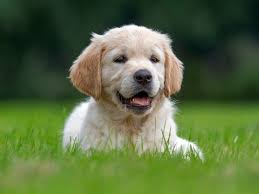

In [38]:
from PIL import Image
img = Image.open("download.jfif")
img

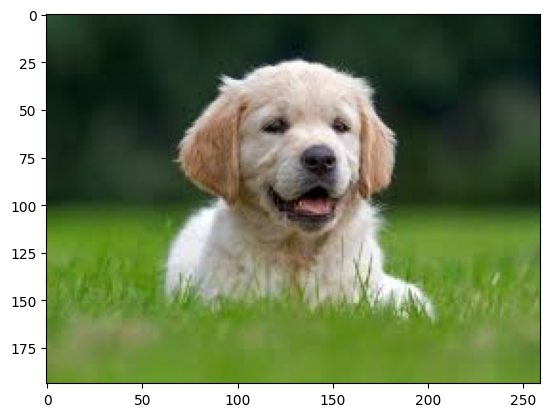

In [53]:
import matplotlib.pyplot as plt
plt.imshow(img);

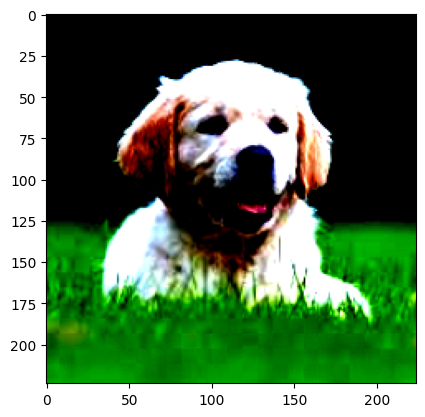

In [52]:
# size cua vgg 224 - 224 -> resize

resize = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

transform = BaseTransform(resize, mean, std) # make transform
img_transformed = transform(img) # transform input image

img_transformed = img_transformed.numpy().transpose(1,2,0)
img_transformed = np.clip(img_transformed, 0, 1)
plt.imshow(img_transformed);


In [58]:
Pipeline:
(1) Load image (PIL)
        ↓
(2) Resize / Crop → right input size
        ↓
(3) ToTensor
        ↓
(4) Normalize (mean/std of pretrained)
        ↓
(5) Add batch dimension (unsqueeze)
        ↓
(6) Model.eval()
        ↓
(7) Forward → output / feature

SyntaxError: invalid character '↓' (U+2193) (503358088.py, line 3)

In [ ]:
#Recommend Ytb:
- 3Blue1Brown convolutional neural networks
- Aladdin Persson VGG16 PyTorch
- StatQuest image normalization deep learning
- PyTorch CNN image classification tutorial